In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Descargar data
Puedes usar el código si configuras tu entorno
En cualquier caso puedes descargar la data desde [Data Give me some credit](https://www.kaggle.com/competitions/give-me-some-credit/data)

In [24]:
# Descargar data desde Kaggle
# tienes que tener tu configuración de kaggle
"""
import kagglehub

# Download latest version
path = kagglehub.competition_download('give-me-some-credit')

print("Path to competition files:", path)
"""

'\nimport kagglehub\n\n# Download latest version\npath = kagglehub.competition_download(\'give-me-some-credit\')\n\nprint("Path to competition files:", path)\n'

In [25]:
#subir directamente si estás trabajando desde Colab
"""
from google.colab import drive
drive.mount('/content/drive')
path_train= "/content/drive/MyDrive/data/train.csv"
path_test = "/content/drive/MyDrive/data/test.csv"
"""

'\nfrom google.colab import drive\ndrive.mount(\'/content/drive\')\npath_train= "/content/drive/MyDrive/data/train.csv"\npath_test = "/content/drive/MyDrive/data/test.csv"\n'

In [26]:
#en caso hacerlo en local
path_train = "data/train.csv"
path_test = "data/test.csv"

In [27]:
df_train= pd.read_csv(path_train)
df_test = pd.read_csv(path_test)

C:\Users\Diego Roman\AppData\Local\Temp\ipykernel_13148\352102316.py:1: DtypeWarning: Columns (0: Id, 1: SeriousDlqin2yrs, 2: RevolvingUtilizationOfUnsecuredLines, 3: age, 4: NumberOfTime30-59DaysPastDueNotWorse, 5: DebtRatio, 6: MonthlyIncome, 7: NumberOfOpenCreditLinesAndLoans, 8: NumberOfTimes90DaysLate, 9: NumberRealEstateLoansOrLines, 10: NumberOfTime60-89DaysPastDueNotWorse, 11: NumberOfDependents) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train= pd.read_csv(path_train)


# Exploración de los datos
En esta parte primero notaremos como se comportan los datos, teniendo en cuenta los outliers, nulos, porcentaje, para luego hacer el tratamiento de los datos

## Data Dictionary - English


|Variable Name|Description|Type|
|--------------|-----------|------|
|**SeriousDlqin2yrs(target)**|**Person experienced 90 days past due delinquency or worse** |**Y/N**|
|RevolvingUtilizationOfUnsecuredLines|Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits|percentage|
|age|Age of borrower in years|integer|
|NumberOfTime30-59DaysPastDueNotWorse|Number of times borrower has been 30-59 days past due but no worse in the last 2 years|integer|
|DebtRatio|"Monthly debt payments alimony,living costs divided by monthy gross income"|percentage|
|MonthlyIncome|Monthly income,real NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards)|integer|
|NumberOfTimes90DaysLate|Number of times borrower has been 90 days or more past due|integer|
|NumberRealEstateLoansOrLines|Number of mortgage and real estate loans including home equity lines of credit|integer|
|NumberOfTime60-89DaysPastDueNotWorse|Number of times borrower has been 60-89 days past due but no worse in the last 2 years|integer|
|NumberOfDependents|"Number of dependents in family excluding themselves (spouse, children etc.)"|integer|

### Diccionario de Datos - Español

|Variable Name|Descripción|Tipo|
|--------------|-----------|------|
|SeriousDlqin2yrs|Persona que ha experimentado mora de 90 días o peor|Y/N|
|RevolvingUtilizationOfUnsecuredLines|Saldo total en tarjetas de crédito y líneas de crédito personales, excluyendo bienes raíces y deudas a plazos como préstamos de automóviles, dividido por la suma de los límites de crédito|porcentaje|
|age|Edad del prestatario en años|entero|
|NumberOfTime30-59DaysPastDueNotWorse|Número de veces que el prestatario ha tenido mora de 30-59 días pero no peor en los últimos 2 años|entero|
|DebtRatio|Pagos mensuales de deuda, pensión alimenticia y costos de vida divididos por el ingreso bruto mensual|porcentaje|
|MonthlyIncome|Ingreso mensual|real|
|NumberOfOpenCreditLinesAndLoans|Número de préstamos abiertos (a plazos como préstamo de automóvil o hipoteca) y líneas de crédito (por ejemplo, tarjetas de crédito)|entero|
|NumberOfTimes90DaysLate|Número de veces que el prestatario ha tenido mora de 90 días o más|entero|
|NumberRealEstateLoansOrLines|Número de préstamos hipotecarios y de bienes raíces, incluidas las líneas de crédito con garantía hipotecaria|entero|
|NumberOfTime60-89DaysPastDueNotWorse|Número de veces que el prestatario ha tenido mora de 60-89 días pero no peor en los últimos 2 años|entero|
|NumberOfDependents|Número de dependientes en la familia, excluyéndose a sí mismo (cónyuge, hijos, etc.)|entero|





In [28]:
df_train.head(10)

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
1,2,0,0.65818,38,1,0.085113,3042.0,2,1,0,0,0.0
2,3,0,0.23381,30,0,0.03605,3300.0,5,0,0,0,0.0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
5,6,0,0.305682,57,0,5710.0,NaN,8,0,3,0,0.0
6,7,0,0.754464,39,0,0.20994,3500.0,8,0,0,0,0.0
7,8,0,0.116951,27,0,46.0,NaN,2,0,0,0,NaN
8,10,0,0.644226,30,0,0.309476,2500.0,5,0,0,0,0.0
9,11,0,0.018798,51,0,0.531529,6501.0,7,0,2,0,2.0


In [29]:
df_train.tail(10)

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
104796,149983,0,0.002484811,82,0,0.00079984,5000.0,5,0,0,0,0.0
104797,149986,0,0.168101659,49,0,0.080383923,5000.0,16,0,0,0,1.0
104798,149987,0,0.9999998999999999,28,0,0.055692307999999996,3249.0,3,1,0,0,0.0
104799,149988,0,0.9020505529999999,31,1,0.34792442799999995,7515.0,10,0,1,0,0.0
104800,149990,0,0.055518162999999995,46,0,0.609778598,4335.0,7,0,1,0,2.0
104801,149991,0,0.1041117,59,0,0.47765823399999996,10316.0,10,0,2,0,0.0
104802,149993,0,0.9999998999999999,22,0,0.0,820.0,1,0,0,0,0.0
104803,149998,0,0.0,30,0,0.0,5716.0,4,0,0,0,0.0
104804,149999,0,0.850282951,64,0,0.249908077,8158.0,8,0,2,0,0.0
104805,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents


In [30]:
df_test.head(10)

,Id,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,9,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0
2,17,0.166284,53,0,0.188274,8800.0,7,0,0,0,0.0
3,18,0.221813,43,0,0.527888,3280.0,7,0,1,0,2.0
4,24,0.046560,58,0,0.241622,2416.0,9,0,1,0,0.0
5,26,0.052436,58,0,0.097672,8333.0,22,0,1,0,0.0
6,31,1.000000,24,0,0.472703,750.0,1,0,0,0,0.0
7,34,0.693330,42,2,0.257732,2230.0,7,0,0,0,0.0
8,35,0.000000,64,0,0.073539,11000.0,9,0,1,0,0.0
9,37,1.000000,75,1,0.134078,3400.0,1,0,1,0,1.0


In [31]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 104806 entries, 0 to 104805
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype 
---  ------                                --------------   ----- 
 0   Id                                    104806 non-null  object
 1   SeriousDlqin2yrs                      104806 non-null  object
 2   RevolvingUtilizationOfUnsecuredLines  104806 non-null  object
 3   age                                   104806 non-null  object
 4   NumberOfTime30-59DaysPastDueNotWorse  104806 non-null  object
 5   DebtRatio                             104806 non-null  object
 6   MonthlyIncome                         84025 non-null   object
 7   NumberOfOpenCreditLinesAndLoans       104806 non-null  object
 8   NumberOfTimes90DaysLate               104806 non-null  object
 9   NumberRealEstateLoansOrLines          104806 non-null  object
 10  NumberOfTime60-89DaysPastDueNotWorse  104806 non-null  object
 11  NumberOfDependents      

Vamos a hacer un casting de los datos para que tengan el dato correcto

In [32]:
import pandas as pd
import numpy as np

def convertir_tipos_datos(df):
    # Hacemos una copia para no modificar el DataFrame original
    df_conv = df.copy()
    
    # 1. Target: Y/N -> 1/0 (tipo entero pequeño, ideal para modelos de clasificación)
    # Se usa .astype(str) por si hay valores numéricos o mixtos en la columna
    
    df_conv['SeriousDlqin2yrs'] = (
        df_conv['SeriousDlqin2yrs'].astype(str).map({'1': 1, '0': 0})
        .astype('Int8')  # Entero de 8 bits con soporte para NaN
    )
    
    
    # 2. ID: convertir a numérico (se recomienda eliminarlo antes de entrenar modelos)
    df_conv['Id'] = pd.to_numeric(df_conv['Id'], errors='coerce').astype('Int64')
    
    # 3. Definir columnas según el diccionario
    float_cols = [
        'RevolvingUtilizationOfUnsecuredLines',
        'DebtRatio',
        'MonthlyIncome'
    ]
    
    int_cols = [
        'age',
        'NumberOfTime30-59DaysPastDueNotWorse',
        'NumberOfOpenCreditLinesAndLoans',
        'NumberOfTimes90DaysLate',
        'NumberRealEstateLoansOrLines',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'NumberOfDependents'
    ]
    
    # 4. Conversión segura: strings/espacios/caracteres extra -> numérico, errores -> NaN
    all_numeric = float_cols + int_cols
    for col in all_numeric:
        df_conv[col] = pd.to_numeric(df_conv[col], errors='coerce')
        
    # 5. Asignar tipos finales optimizados
    for col in float_cols:
        df_conv[col] = df_conv[col].astype('float32')  # float32 ahorra ~50% de memoria vs float64
        
    for col in int_cols:
        df_conv[col] = df_conv[col].astype('Int32')    # Int32 es un "nullable integer" de pandas
        
    return df_conv

# Aplicar la función
# df = tu_dataframe_original
df_train = convertir_tipos_datos(df_train)

# Verificación rápida
print(df_train.info())
print("\nValores nulos por columna:")
print(df_train.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 104806 entries, 0 to 104805
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  Int64  
 1   SeriousDlqin2yrs                      104805 non-null  Int8   
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float32
 3   age                                   104805 non-null  Int32  
 4   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  Int32  
 5   DebtRatio                             104805 non-null  float32
 6   MonthlyIncome                         84024 non-null   float32
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  Int32  
 8   NumberOfTimes90DaysLate               104805 non-null  Int32  
 9   NumberRealEstateLoansOrLines          104805 non-null  Int32  
 10  NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  Int32  
 11  NumberOfDep

In [33]:
#porcentaje de nulos para la fila MonthlyIncome
porcentaje_nulos_MonthlyIncome = (df_train.isna().sum()/len(df_train))*100
print("==============PORCENTAJE DE VALORES NULOS========================")
print(porcentaje_nulos_MonthlyIncome)

==============PORCENTAJE DE VALORES NULOS========================
Id                                       0.000954
SeriousDlqin2yrs                         0.000954
RevolvingUtilizationOfUnsecuredLines     0.000954
age                                      0.000954
NumberOfTime30-59DaysPastDueNotWorse     0.000954
DebtRatio                                0.000954
MonthlyIncome                           19.829017
NumberOfOpenCreditLinesAndLoans          0.000954
NumberOfTimes90DaysLate                  0.000954
NumberRealEstateLoansOrLines             0.000954
NumberOfTime60-89DaysPastDueNotWorse     0.000954
NumberOfDependents                       2.623896
dtype: float64


Notamos que existe un 29.82 porciento de valores nulos en MonthlyIncome y un 2.62 de valores nulos en NumberOfDependents

In [34]:
df_train.describe()

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,104805.0,104805.0,104805.000000,104805.0,104805.0,104805.000000,8.402400e+04,104805.0,104805.0,104805.0,104805.0,102056.0
mean,75013.710863,0.066314,5.602015,52.351128,0.416077,354.859497,6.684453e+03,8.454854,0.259988,1.019551,0.235571,0.756065
std,43324.043054,0.248831,217.389877,14.765944,4.139291,2169.182861,1.565313e+04,5.127986,4.115594,1.136847,4.101263,1.112162
min,1.0,0.0,0.000000,0.0,0.0,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0
25%,37508.0,0.0,0.029801,41.0,0.0,0.175026,3.400000e+03,5.0,0.0,0.0,0.0,0.0
50%,74931.0,0.0,0.153984,52.0,0.0,0.366626,5.400000e+03,8.0,0.0,1.0,0.0,0.0
75%,112620.0,0.0,0.559168,63.0,0.0,0.867267,8.250000e+03,11.0,0.0,2.0,0.0,1.0
max,149999.0,1.0,29110.000000,109.0,98.0,329664.000000,3.008750e+06,58.0,98.0,54.0,98.0,13.0


Vamos a explorar con gráficos un poco

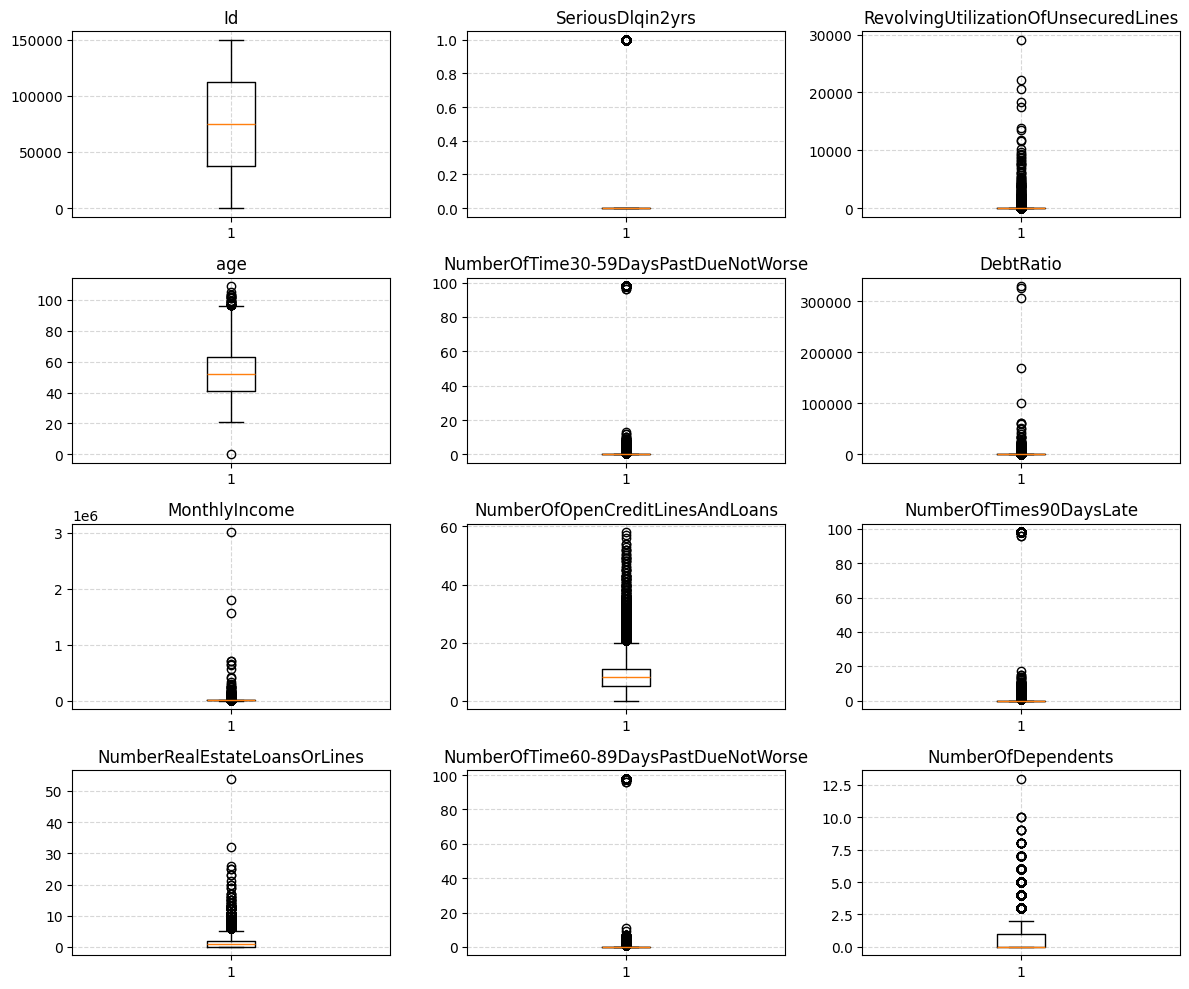

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
ax = ax.flatten()  # Aplana la matriz 4x3 a un array 1D para iterar fácilmente

for i, col in enumerate(df_train.columns):
    if i < len(ax):
        # dropna() evita errores si hay valores faltantes
        ax[i].boxplot(df_train[col].dropna())
        ax[i].set_title(col)
        ax[i].grid(True, linestyle='--', alpha=0.5)

# Oculta los subplots sobrantes si hay menos columnas que ejes
for j in range(len(df_train.columns), len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

## Conclusiones a partir del boxplot
1. Age: Se puede notar que las personas que tiene 0 de edad no pueden sacar algún prestamo, así que eliminamos a esas personas.
2. NumberOfTime30-59DaysPastDueNotWorse: Parecen que hay algunos outliers después de 80
3. DebRatio: Algunos valores no tienen que pasan 300000
4. MonthlyIncome: No parecen valores aticos pero si algunos no son pertenecientes, como el aquellos que ganan más de 1e6
5. NumberOfTimes90DaysLate: Existe algunos outliers que están después de 80
6. NumberRealEstateLoansOrLines: Existen valores mayores a 30 que parecen ser outliers
7. NumberOfTime60-89DaysPastDueNotWorse: Los valores que están después de 100 pueden ser outliers


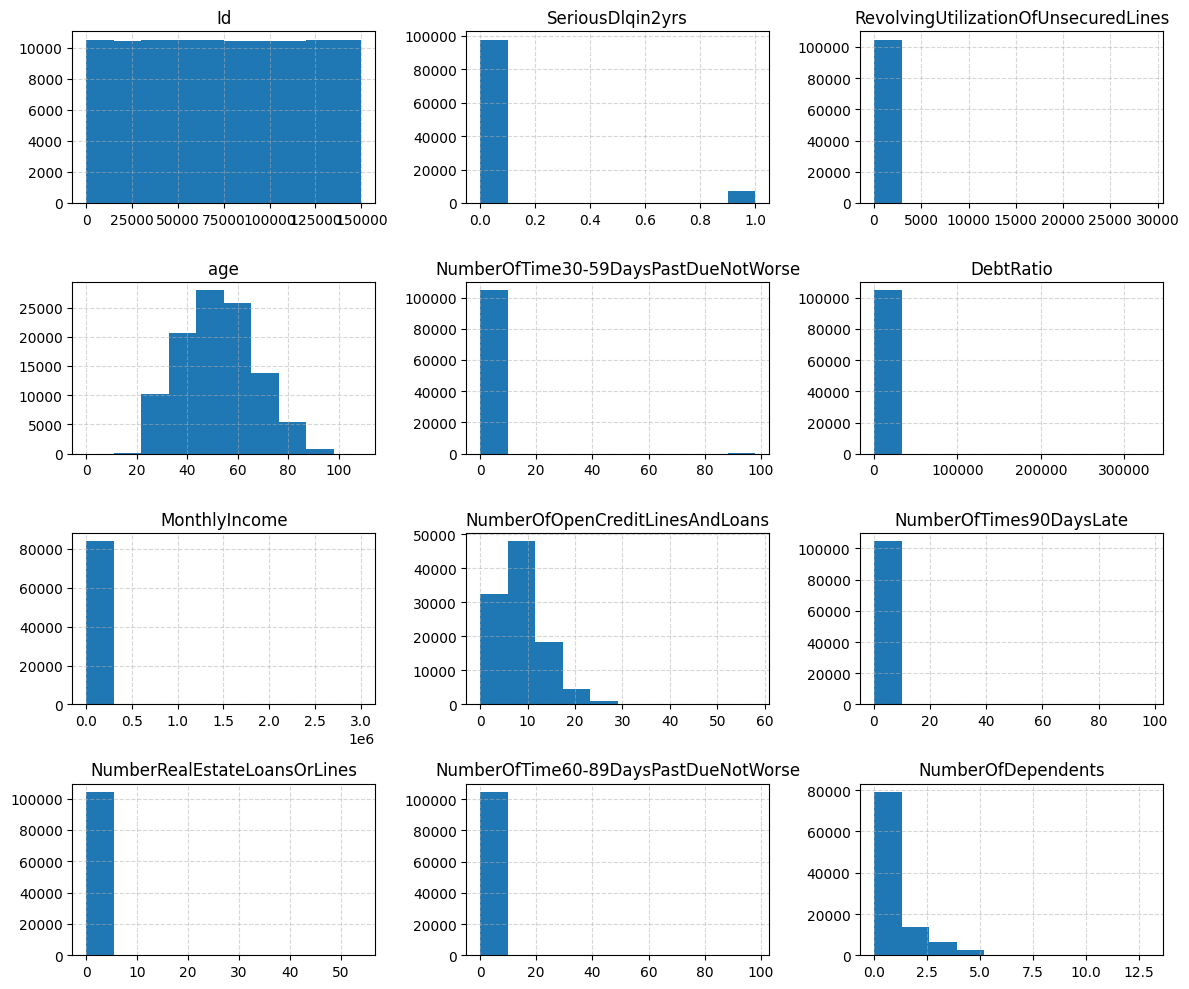

In [36]:
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
ax = ax.flatten()  # Aplana la matriz 4x3 a un array 1D para iterar fácilmente

for i, col in enumerate(df_train.columns):
    if i < len(ax):
        # dropna() evita errores si hay valores faltantes
        ax[i].hist(df_train[col].dropna())
        ax[i].set_title(col)
        ax[i].grid(True, linestyle='--', alpha=0.5)

# Oculta los subplots sobrantes si hay menos columnas que ejes
for j in range(len(df_train.columns), len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

# Pasamos a la limpieza de datos

In [37]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 104806 entries, 0 to 104805
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  Int64  
 1   SeriousDlqin2yrs                      104805 non-null  Int8   
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float32
 3   age                                   104805 non-null  Int32  
 4   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  Int32  
 5   DebtRatio                             104805 non-null  float32
 6   MonthlyIncome                         84024 non-null   float32
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  Int32  
 8   NumberOfTimes90DaysLate               104805 non-null  Int32  
 9   NumberRealEstateLoansOrLines          104805 non-null  Int32  
 10  NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  Int32  
 11  NumberOfDep

In [38]:
df_train_clean = df_train.copy()
df_train_clean['MonthlyIncome_Missing'] = df_train_clean['MonthlyIncome'].apply(lambda x: 1 if pd.isna(x) else 0)

#### **¿Por qué se añade esta columna?**
Este addicion de columna se debe a que cuando se aplique el modelo de clasificación, entienda que 1 está correlacionado con un mayor o menor riesgo de impago, independiente del número con el que rellenes el ingreso después

In [39]:
df_train_clean[['MonthlyIncome_Missing','MonthlyIncome']].head(10)

,MonthlyIncome_Missing,MonthlyIncome
0,0,2600.0
1,0,3042.0
2,0,3300.0
3,0,63588.0
4,0,3500.0
5,1,NaN
6,0,3500.0
7,1,NaN
8,0,2500.0
9,0,6501.0


#### ¿Aplicar Inputacion Multivariada (MICE)?
Vamos aplicar MICE llenar datos a través de la regresion de datos basandonos en factores como **age, DebtRatio y NumberOfDependents** 

In [40]:
## Aplicacion de Inputacion Multivariada(MICE por su siglas en ingles)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# 1. Seleccionar las columnas involucradas en la imputación
cols_impute = ['MonthlyIncome', 'age', 'DebtRatio', 'NumberOfDependents']
df_subset = df_train_clean[cols_impute].copy()

# 2. Convertir a float64 y pasar <NA> (pandas) a np.nan (numpy/sklearn)
# IterativeImputer requiere matrices numéricas sin el tipo nullable de pandas
df_subset = df_subset.astype('float64')

# 3. Configurar MICE con un estimador robusto para datos tabulares
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    max_iter=10,          # Número de rondas de imputación (10 suele ser suficiente)
    random_state=42,      # Reproducibilidad
    sample_posterior=False, # False = imputación determinista (recomendado para ML)
    skip_complete=True    # Ignora filas sin nulos para acelerar
)

# 4. Ajustar y transformar
imputed_array = imputer.fit_transform(df_subset)

# 5. Reemplazar SOLO MonthlyIncome en el DataFrame original
df_train_clean['MonthlyIncome'] = imputed_array[:, 0]

# Verificación rápida
print("Nulos en MonthlyIncome después de imputar:", df_train_clean['MonthlyIncome'].isna().sum())
print("Rango de valores imputados:", df_train_clean['MonthlyIncome'].describe())

Nulos en MonthlyIncome después de imputar: 0
Rango de valores imputados: count    1.048060e+05
mean     5.465591e+03
std      1.424882e+04
min      0.000000e+00
25%      1.880000e+03
50%      4.484000e+03
75%      7.500000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64
